In [55]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from  sklearn.metrics  import *
import tensorflow as tf 
import keras 
from keras.layers  import Dense,Flatten
from keras.models import Sequential
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [11]:
dataPath = '/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/dogs-vs-cats'
testPath = '/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/dogs-vs-cats/test1'
trainPath = '/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/dogs-vs-cats/train'

In [12]:
os.listdir(dataPath)

['sampleSubmission.csv',
 'test1',
 'cats-vs-dogs-image-classification-using-cnn.ipynb',
 'train']

In [23]:
filesnames = os.listdir(trainPath)
labels = [ x.split(".")[0] for x in filesnames]
set(labels)

{'cat', 'dog'}

In [27]:
data = pd.DataFrame({'filesname':filesnames,'label':labels})
data['label'].value_counts()

label
cat    12545
dog    12530
Name: count, dtype: int64

In [29]:
data.head()

,filesname,label
0,dog.8011.jpg,dog
1,cat.5077.jpg,cat
2,dog.7322.jpg,dog
3,cat.2718.jpg,cat
4,cat.10151.jpg,cat


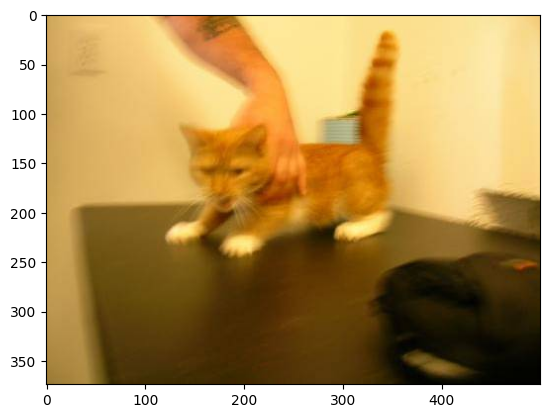

In [34]:
img = Image.open('/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/dogs-vs-cats/train/cat.0.jpg')
plt.imshow(img)
plt.show()

In [50]:
#Display random images of each class 
def display_random_images(label1='dog',image_count=5):
    filterdata = data[data['label']==label1]
    filterdata = filterdata.sample(image_count)
    for i in range(image_count):
        img = Image.open(trainPath+'/'+filterdata.iloc[i]['filesname'])
        print(np.array(img).shape)
        plt.imshow(img)
        plt.show()

(499, 333, 3)


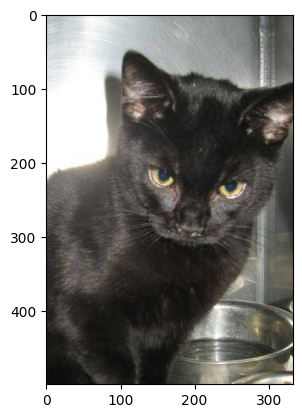

(400, 399, 3)


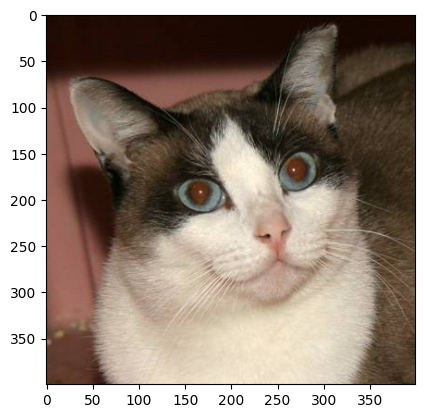

(500, 276, 3)


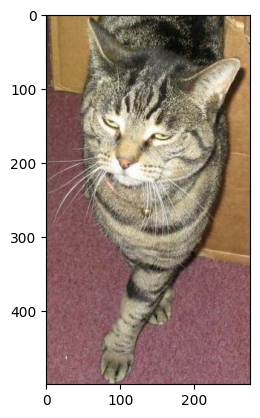

(375, 499, 3)


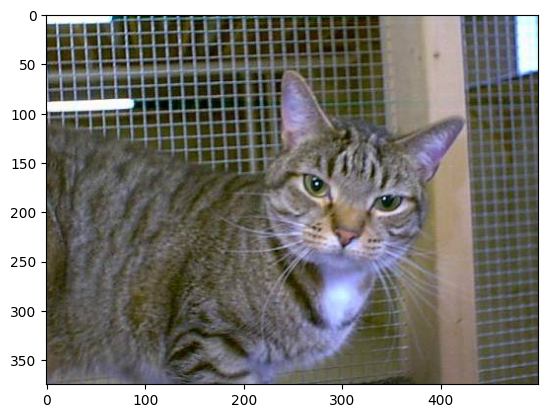

(270, 354, 3)


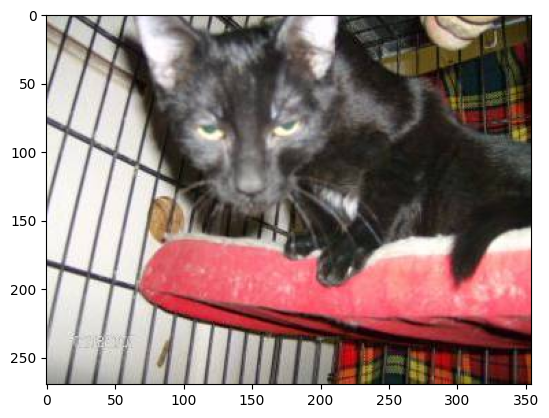

In [54]:
display_random_images('cat',5)


In [56]:
train_df, test_df = train_test_split(data,test_size=0.3,random_state=42)

In [57]:
train_df.shape

(17552, 2)

In [59]:
test_df['label'].value_counts()

label
dog    3765
cat    3758
Name: count, dtype: int64

In [60]:
trian_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [61]:
train_generator = trian_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=trainPath,
    x_col='filesname',
    y_col='label',
    class_mode='binary',
    target_size=(128,128),
    batch_size=32
)

Found 17552 validated image filenames belonging to 2 classes.


In [62]:
test_generator = trian_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=trainPath,
    x_col='filesname',
    y_col='label',
    class_mode='binary',
    target_size=(128,128),
    batch_size=32
)

Found 7523 validated image filenames belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 39690)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,080,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,080,857 (19.38 MB)

 Trainable params: 5,080,857 (19.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
549/549 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.5652 - loss: 0.6814 - val_accuracy: 0.6097 - val_loss: 0.6612
Epoch 2/5
549/549 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.6160 - loss: 0.6513 - val_accuracy: 0.6271 - val_loss: 0.6421
Epoch 3/5
549/549 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.6463 - loss: 0.6269 - val_accuracy: 0.6517 - val_loss: 0.6192
Epoch 4/5
549/549 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.6716 - loss: 0.6027 - val_accuracy: 0.6693 - val_loss: 0.6036
Epoch 5/5
549/549 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.6890 - loss: 0.5849 - val_accuracy: 0.6871 - val_loss: 0.5864


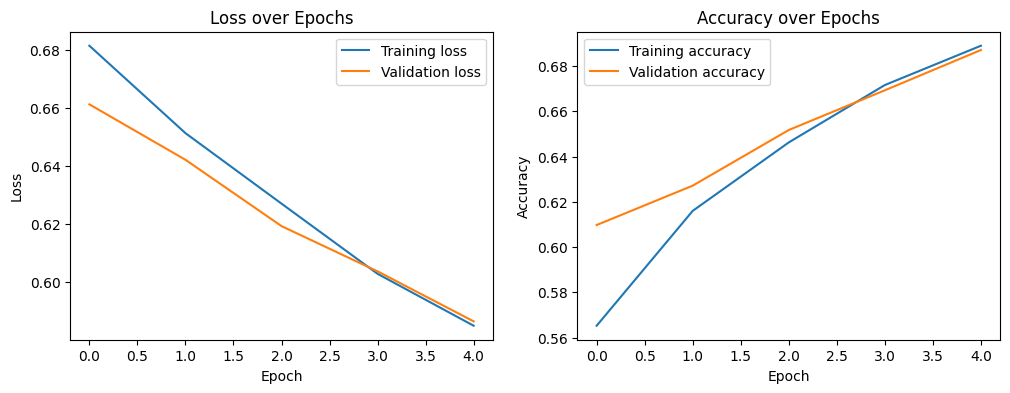

In [67]:
model2  = Sequential(
    [    
         keras.layers.Conv2D(10,(3,3),activation='relu',input_shape=(128,128,3)),
            keras.layers.MaxPool2D((2,2)),
        Flatten(),
        Dense(128,activation='relu'),
        
       
        Dense(1,activation='sigmoid')
    ]
)
model2.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])
model2.summary()
history2 = model2.fit(train_generator ,epochs=5,validation_data=test_generator)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history2.history['loss'],label='Training loss')
plt.plot(history2.history['val_loss'],label='Validation loss')
plt.title("Loss over Epochs")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history2.history['accuracy'],label='Training accuracy')
plt.plot(history2.history['val_accuracy'],label='Validation accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
